In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpnm as op
from scipy.stats import weibull_min

In [2]:
def make_randomized_cubic_network(
    shape=(12, 12, 12),
    spacing=1.0e-5,
    connectivity=26,
    trim_fraction=0.15,
    seed=0,
):
    rng = np.random.default_rng(seed)
    pn = op.network.Cubic(shape=shape, spacing=spacing, connectivity=connectivity)
    Nt = pn.Nt
    n_trim = int(trim_fraction * Nt)

    if n_trim > 0:
        throats_to_trim = rng.choice(pn.throats(), size=n_trim, replace=False)
        op.topotools.trim(network=pn, throats=throats_to_trim)

    health = op.utils.check_network_health(pn)
    disconnected = health["disconnected_pores"]
    if len(disconnected) > 0:
        op.topotools.trim(network=pn, pores=disconnected)

    return pn

In [3]:
def add_geometry_and_sizes(
    pn,
    pore_shape,
    pore_scale,
    throat_ratio,
    seed=0,
):
    rng = np.random.default_rng(seed)

    pn["pore.seed"] = rng.random(pn.Np)

    pn.add_model(
        propname="pore.diameter",
        model=op.models.geometry.pore_size.weibull,
        shape=pore_shape,
        scale=pore_scale,
        loc=0.0,
        seeds="pore.seed",
    )
    pn.regenerate_models()

    conns = pn["throat.conns"]
    p1 = conns[:, 0]
    p2 = conns[:, 1]

    pn["throat.seed"] = np.minimum(pn["pore.seed"][p1], pn["pore.seed"][p2])

    pn["throat.max_size"] = np.minimum(
        pn["pore.diameter"][p1],
        pn["pore.diameter"][p2]
    )

    pn["throat.diameter"] = throat_ratio * pn["throat.max_size"]

    pn["pore.volume"] = (np.pi / 6.0) * pn["pore.diameter"]**3

    coords = pn["pore.coords"]
    c1 = coords[p1]
    c2 = coords[p2]
    center_dist = np.linalg.norm(c2 - c1, axis=1)

    throat_length = center_dist - 0.5 * (
        pn["pore.diameter"][p1] + pn["pore.diameter"][p2]
    )

    throat_length = np.clip(throat_length, 1e-12, None)
    pn["throat.length"] = throat_length

    pn["throat.area"] = (np.pi / 4.0) * pn["throat.diameter"]**2
    pn["throat.volume"] = pn["throat.area"] * pn["throat.length"]

    return pn

In [4]:
def inspect_network_basic(pn):
    print(pn)
    print(f"Number of pores   : {pn.Np}")
    print(f"Number of throats : {pn.Nt}")

    if "pore.coordination_number" not in pn.keys():
        pn.add_model(
            propname="pore.coordination_number",
            model=op.models.network.coordination_number,
        )
        pn.regenerate_models()

    z = pn["pore.coordination_number"]
    print(f"Mean coordination : {np.mean(z):.3f}")
    print(f"Std coordination  : {np.std(z):.3f}")

In [5]:
def compute_absolute_permeability(
    pn,
    shape=(12, 12, 12),
    spacing=1.0e-5,
    axis="x",
    mu=1.0e-3,
    dP=1.0,
):
    phase = op.phase.Phase(network=pn)

    r = 0.5 * pn["throat.diameter"]
    L = pn["throat.length"]
    g = np.pi * r**4 / (8.0 * mu * L)

    phase["throat.hydraulic_conductance"] = g

    sf = op.algorithms.StokesFlow(network=pn, phase=phase)

    if axis == "x":
        inlet = pn.pores("left")
        outlet = pn.pores("right")
        Ldom = (shape[0] - 1) * spacing
        A = ((shape[1] - 1) * spacing) * ((shape[2] - 1) * spacing)
    elif axis == "y":
        inlet = pn.pores("front")
        outlet = pn.pores("back")
        Ldom = (shape[1] - 1) * spacing
        A = ((shape[0] - 1) * spacing) * ((shape[2] - 1) * spacing)
    elif axis == "z":
        inlet = pn.pores("bottom")
        outlet = pn.pores("top")
        Ldom = (shape[2] - 1) * spacing
        A = ((shape[0] - 1) * spacing) * ((shape[1] - 1) * spacing)
    else:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    sf.set_value_BC(pores=inlet, values=dP)
    sf.set_value_BC(pores=outlet, values=0.0)
    sf.run()

    Q = sf.rate(pores=inlet).sum()

    K = (Q / A) * (mu * Ldom / dP)
    return float(K)

In [6]:
def compute_basic_features(
    pn,
    shape=(12, 12, 12),
    spacing=1.0e-5,
    axis="x",
):
    if "pore.coordination_number" not in pn.keys():
        pn.add_model(
            propname="pore.coordination_number",
            model=op.models.network.coordination_number,
        )
        pn.regenerate_models()

    z = pn["pore.coordination_number"]

    if axis == "x":
        Ldom = (shape[0] - 1) * spacing
        A = ((shape[1] - 1) * spacing) * ((shape[2] - 1) * spacing)
    elif axis == "y":
        Ldom = (shape[1] - 1) * spacing
        A = ((shape[0] - 1) * spacing) * ((shape[2] - 1) * spacing)
    elif axis == "z":
        Ldom = (shape[2] - 1) * spacing
        A = ((shape[0] - 1) * spacing) * ((shape[1] - 1) * spacing)
    else:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    V_bulk = A * Ldom
    V_void = np.sum(pn["pore.volume"]) + np.sum(pn["throat.volume"])
    porosity = V_void / V_bulk

    feats = {
        "Np": pn.Np,
        "Nt": pn.Nt,
        "coord_mean": float(np.mean(z)),
        "coord_std": float(np.std(z)),
        "pore_diam_mean": float(np.mean(pn["pore.diameter"])),
        "pore_diam_std": float(np.std(pn["pore.diameter"])),
        "throat_diam_mean": float(np.mean(pn["throat.diameter"])),
        "throat_diam_std": float(np.std(pn["throat.diameter"])),
        "porosity": float(porosity),
        "bulk_length": float(Ldom),
        "bulk_area": float(A),
        "bulk_volume": float(V_bulk),
    }
    return feats

In [7]:
def compute_effective_diffusivity(
    pn,
    shape=(12, 12, 12),
    spacing=1.0e-5,
    axis="x",
    D_AB=2.0e-9,
    C_in=1.0,
    C_out=0.0,
):
    phase = op.phase.Phase(network=pn)

    g_diff = D_AB * pn["throat.area"] / pn["throat.length"]
    phase["throat.diffusive_conductance"] = g_diff

    fd = op.algorithms.FickianDiffusion(network=pn, phase=phase)

    if axis == "x":
        inlet = pn.pores("left")
        outlet = pn.pores("right")
        Ldom = (shape[0] - 1) * spacing
        A = ((shape[1] - 1) * spacing) * ((shape[2] - 1) * spacing)
    elif axis == "y":
        inlet = pn.pores("front")
        outlet = pn.pores("back")
        Ldom = (shape[1] - 1) * spacing
        A = ((shape[0] - 1) * spacing) * ((shape[2] - 1) * spacing)
    elif axis == "z":
        inlet = pn.pores("bottom")
        outlet = pn.pores("top")
        Ldom = (shape[2] - 1) * spacing
        A = ((shape[0] - 1) * spacing) * ((shape[1] - 1) * spacing)
    else:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    fd.set_value_BC(pores=inlet, values=C_in)
    fd.set_value_BC(pores=outlet, values=C_out)
    fd.run()

    rate_inlet = np.asarray(fd.rate(pores=inlet, mode="group")).sum()
    rate_outlet = np.asarray(fd.rate(pores=outlet, mode="group")).sum()

    N_A = max(abs(rate_inlet), abs(rate_outlet))

    Deff = N_A * Ldom / (A * (C_in - C_out))
    return float(Deff)

In [8]:
def compute_tortuosity_from_deff(porosity, Deff, D_AB=2.0e-9):
    tau = porosity * D_AB / Deff
    return float(tau)

In [9]:
def fit_weibull_distribution(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    values = values[values > 0]

    shape, loc, scale = weibull_min.fit(values, floc=0)

    return {
        "shape": float(shape),
        "loc": float(loc),
        "scale": float(scale),
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }

In [10]:
def generate_one_sample(
    sample_id,
    shape=(12, 12, 12),
    spacing=1.0e-5,
    connectivity=26,
    trim_fraction=0.15,
    pore_shape=2.0,
    pore_scale=4.0e-6,
    throat_ratio=0.35,
    seed=0,
):
    pn = make_randomized_cubic_network(
        shape=shape,
        spacing=spacing,
        connectivity=connectivity,
        trim_fraction=trim_fraction,
        seed=seed,
    )

    pn = add_geometry_and_sizes(
        pn=pn,
        pore_shape=pore_shape,
        pore_scale=pore_scale,
        throat_ratio=throat_ratio,
        seed=seed,
    )

    feats = compute_basic_features(
        pn=pn,
        shape=shape,
        spacing=spacing,
        axis="x",
    )

    Kx = compute_absolute_permeability(
        pn=pn,
        shape=shape,
        spacing=spacing,
        axis="x",
        mu=1.0e-3,
        dP=1.0,
    )

    Deff_x = compute_effective_diffusivity(
        pn=pn,
        shape=shape,
        spacing=spacing,
        axis="x",
        D_AB=2.0e-9,
        C_in=1.0,
        C_out=0.0,
    )

    tau_x = compute_tortuosity_from_deff(
        porosity=feats["porosity"],
        Deff=Deff_x,
        D_AB=2.0e-9,
    )
    

    pore_fit = fit_weibull_distribution(pn["pore.diameter"])
    throat_fit = fit_weibull_distribution(pn["throat.diameter"])

    row = {
        "sample_id": sample_id,
        "shape_x": shape[0],
        "shape_y": shape[1],
        "shape_z": shape[2],
        "spacing": spacing,
        "connectivity": connectivity,
        "trim_fraction": trim_fraction,
        "pore_weibull_shape_input": pore_shape,
        "pore_weibull_scale_input": pore_scale,
        "throat_ratio": throat_ratio,
        "seed": seed,
        "Kx": Kx,
        "Deff_x": Deff_x,
        "tau_x": tau_x,

        "PSD_true_weibull_shape": pore_fit["shape"],
        "PSD_true_weibull_loc": pore_fit["loc"],
        "PSD_true_weibull_scale": pore_fit["scale"],
        "PSD_true_mean": pore_fit["mean"],
        "PSD_true_std": pore_fit["std"],
        "PSD_true_min": pore_fit["min"],
        "PSD_true_max": pore_fit["max"],

        "TSD_true_weibull_shape": throat_fit["shape"],
        "TSD_true_weibull_loc": throat_fit["loc"],
        "TSD_true_weibull_scale": throat_fit["scale"],
        "TSD_true_mean": throat_fit["mean"],
        "TSD_true_std": throat_fit["std"],
        "TSD_true_min": throat_fit["min"],
        "TSD_true_max": throat_fit["max"],

    }

    row.update(feats)

    return pn, row

In [11]:
def build_phase1_parameter_table(n_samples=300, base_seed=100):
    rng = np.random.default_rng(base_seed)
    rows = []

    for i in range(n_samples):
        row = {
            "sample_id": i,
            "shape": (12, 12, 12),
            "spacing": 1.0e-5,
            "connectivity": int(rng.choice([6, 14, 18, 20, 26])),
            "trim_fraction": float(rng.uniform(0.00, 0.35)),
            "pore_shape": float(rng.uniform(1.5, 4.5)),
            "pore_scale": float(rng.uniform(2.5e-6, 7.5e-6)),
            "throat_ratio": float(rng.uniform(0.15, 0.75)),
            "seed": int(base_seed + i),
        }
        rows.append(row)

    return pd.DataFrame(rows)

In [12]:
param_table = build_phase1_parameter_table(n_samples=300, base_seed=100)
param_table.head()

,sample_id,shape,spacing,connectivity,trim_fraction,pore_shape,pore_scale,throat_ratio,seed
0,0,"(12, 12, 12)",0.00001,20,0.208794,2.366590,0.000003,0.734193,100
1,1,"(12, 12, 12)",0.00001,26,0.208765,3.870789,0.000007,0.562893,101
2,2,"(12, 12, 12)",0.00001,20,0.343518,2.354220,0.000006,0.498622,102
3,3,"(12, 12, 12)",0.00001,6,0.209969,3.105744,0.000007,0.451168,103
4,4,"(12, 12, 12)",0.00001,6,0.172957,4.493023,0.000007,0.386141,104


In [13]:
results = []
networks = {}

for i, (_, p) in enumerate(param_table.iterrows(), start=1):
    pn, row = generate_one_sample(
        sample_id=int(p["sample_id"]),
        shape=p["shape"],
        spacing=float(p["spacing"]),
        connectivity=int(p["connectivity"]),
        trim_fraction=float(p["trim_fraction"]),
        pore_shape=float(p["pore_shape"]),
        pore_scale=float(p["pore_scale"]),
        throat_ratio=float(p["throat_ratio"]),
        seed=int(p["seed"]),
    )
    results.append(row)
    networks[int(p["sample_id"])] = pn

    if i % 25 == 0 or i == len(param_table):
        print(f"Finished {i}/{len(param_table)} samples")

df = pd.DataFrame(results)
print("Done.")

Finished 25/300 samples
Finished 50/300 samples
Finished 75/300 samples
Finished 100/300 samples
Finished 125/300 samples
Finished 150/300 samples
Finished 175/300 samples
Finished 200/300 samples
Finished 225/300 samples
Finished 250/300 samples
Finished 275/300 samples
Finished 300/300 samples
Done.



══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Cubic at 0x7f85306179d0>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  pore.coords                                                   1728 / 1728
  3  throat.conns                                                11106 / 11106
  4  pore.seed                                                     1728 / 1728
  5  pore.diameter                                                 1728 / 1728
  6  pore.coordination_number                                      1728 / 1728
  7  throat.spacing                                              11106 / 11106
  8  throat.seed                                                 11106 / 11106
  9  throat.max_size                                             11106 / 11106
 10

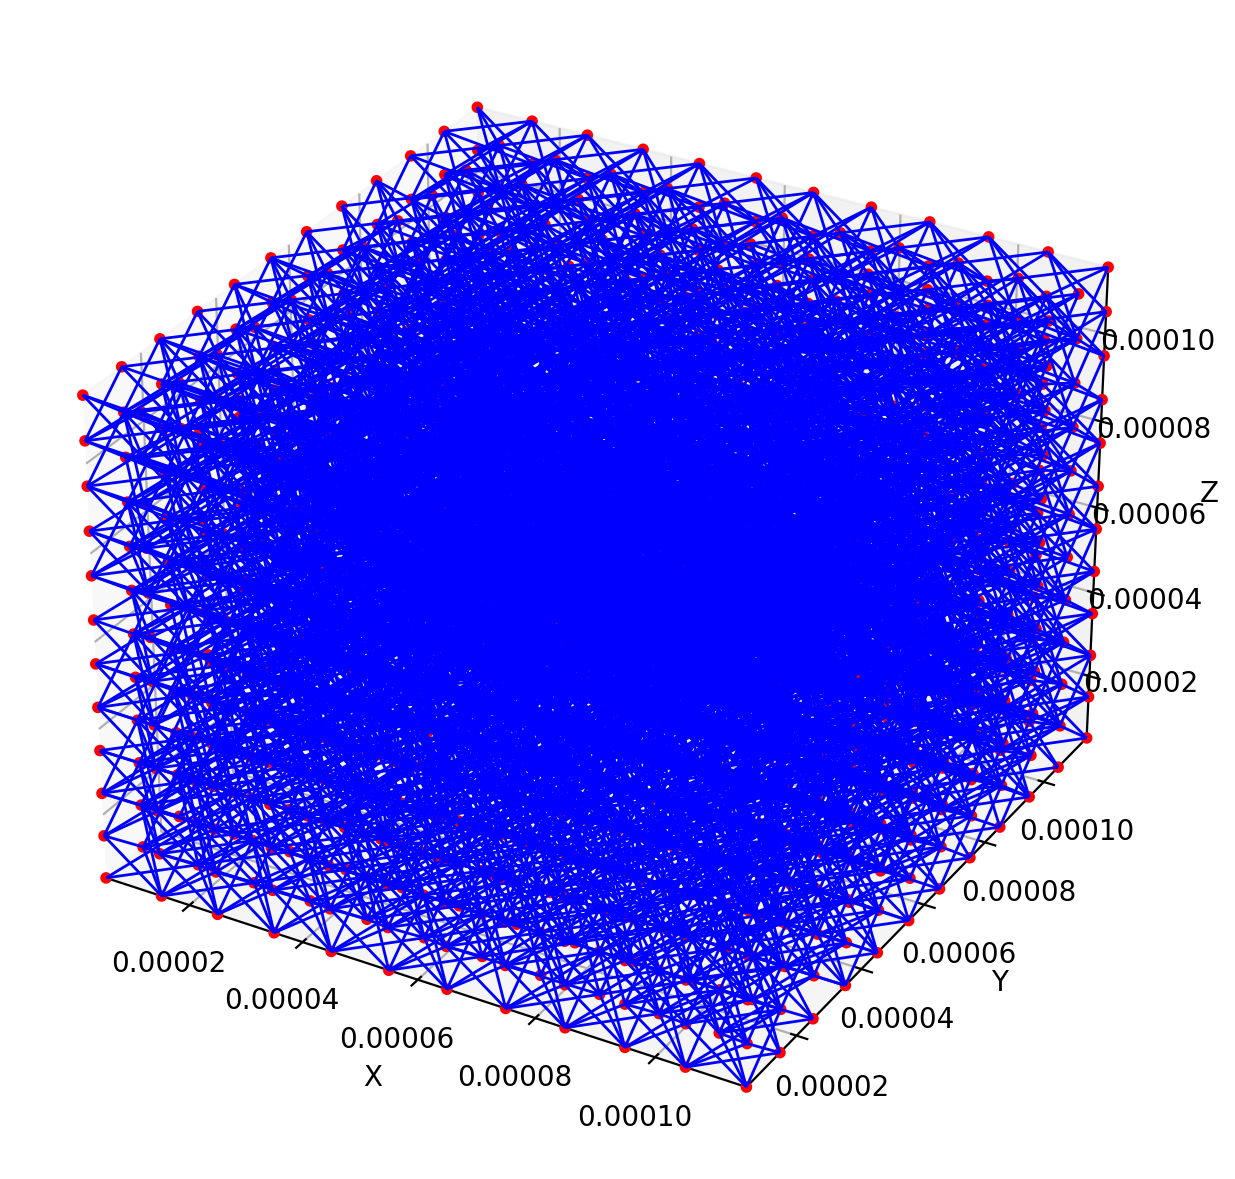

In [14]:
sample_to_plot = 0                  # you can choose from 0 to 299
pn = networks[sample_to_plot]

inspect_network_basic(pn)

fig, ax = plt.subplots(figsize=(6, 6))
op.visualization.plot_coordinates(network=pn, ax=ax)
op.visualization.plot_connections(network=pn, ax=ax)
ax.set_title(f"Sample {sample_to_plot}")
plt.show()

In [15]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

df_display = df.copy()
df_display["Kx"] = df_display["Kx"].map(lambda x: f"{x:.3e}")
df_display["Deff_x"] = df_display["Deff_x"].map(lambda x: f"{x:.3e}")
df_display["tau_x"] = df_display["tau_x"].map(lambda x: f"{x:.3f}")
df_display["porosity"] = df_display["porosity"].map(lambda x: f"{x:.4f}")
df_display["trim_fraction"] = df_display["trim_fraction"].map(lambda x: f"{x:.4f}")
df_display["throat_ratio"] = df_display["throat_ratio"].map(lambda x: f"{x:.4f}")
df_display["PSD_true_weibull_shape"] = df_display["PSD_true_weibull_shape"].map(lambda x: f"{x:.3f}")
df_display["PSD_true_weibull_scale"] = df_display["PSD_true_weibull_scale"].map(lambda x: f"{x:.3e}")
df_display["TSD_true_weibull_shape"] = df_display["TSD_true_weibull_shape"].map(lambda x: f"{x:.3f}")
df_display["TSD_true_weibull_scale"] = df_display["TSD_true_weibull_scale"].map(lambda x: f"{x:.3e}")

main_cols = [
    "sample_id",
    "connectivity",
    "trim_fraction",
    "throat_ratio",
    "porosity",
    "Kx",
    "Deff_x",
    "tau_x",
]

true_cols = [
    "sample_id",
    "PSD_true_weibull_shape",
    "PSD_true_weibull_scale",
    "TSD_true_weibull_shape",
    "TSD_true_weibull_scale",
]

print("=== Main dataset preview ===")
display(df_display[main_cols].sort_values("sample_id").reset_index(drop=True))

print("\n=== True PSD / TSD target preview ===")
display(df_display[true_cols].sort_values("sample_id").reset_index(drop=True))

=== Main dataset preview ===


,sample_id,connectivity,trim_fraction,throat_ratio,porosity,Kx,Deff_x,tau_x
0,0,20,0.2088,0.7342,0.1876,7.931e-15,1.572e-10,2.386
1,1,26,0.2088,0.5629,0.8178,3.298e-13,1.667e-09,0.981
2,2,20,0.3435,0.4986,0.3610,3.749e-14,3.541e-10,2.039
3,3,6,0.2100,0.4512,0.3158,4.176e-14,3.497e-10,1.806
4,4,6,0.1730,0.3861,0.2811,2.475e-14,2.653e-10,2.119
...,...,...,...,...,...,...,...,...
295,295,6,0.1920,0.5829,0.1017,4.117e-15,6.699e-11,3.035
296,296,20,0.0270,0.3017,0.0431,2.172e-16,2.979e-11,2.897
297,297,20,0.1462,0.1522,0.0456,4.653e-17,1.252e-11,7.294
298,298,26,0.0081,0.2417,0.1484,1.846e-15,9.772e-11,3.036



=== True PSD / TSD target preview ===


,sample_id,PSD_true_weibull_shape,PSD_true_weibull_scale,TSD_true_weibull_shape,TSD_true_weibull_scale
0,0,2.429,2.726e-06,2.391,1.498e-06
1,1,3.849,7.044e-06,3.960,3.305e-06
2,2,2.374,5.722e-06,2.358,2.140e-06
3,3,3.077,7.476e-06,3.002,2.694e-06
4,4,4.504,7.387e-06,4.499,2.446e-06
...,...,...,...,...,...
295,295,2.365,4.292e-06,2.351,1.878e-06
296,296,2.599,2.496e-06,2.625,5.798e-07
297,297,2.175,3.450e-06,2.167,3.820e-07
298,298,1.872,4.550e-06,1.927,7.603e-07


# Cleaning Data

In [16]:
D_AB = 2.0e-9

df["flag_Deff_gt_DAB"] = df["Deff_x"] > D_AB
df["flag_tau_lt_1"] = df["tau_x"] < 1.0
df["flag_bad"] = df["flag_Deff_gt_DAB"] | df["flag_tau_lt_1"]

df["flag_bad_strict"] = (df["Deff_x"] > D_AB) | (df["tau_x"] < 0.95)
df["flag_bad_soft"] = ((df["tau_x"] >= 0.95) & (df["tau_x"] < 1.0))

df_clean = df[(df["Deff_x"] <= D_AB) & (df["tau_x"] >= 1.0)].copy()

print("=" * 55)
print("Diffusivity and Tortuosity Quality Control Summary")
print("=" * 55)
print(f"Reference free diffusivity D_AB : {D_AB:.2e} m^2/s")
print(f"Total generated samples         : {len(df)}")
print(f"Samples with Deff_x > D_AB      : {df['flag_Deff_gt_DAB'].sum()}")
print(f"Samples with tau_x < 1          : {df['flag_tau_lt_1'].sum()}")
print(f"Total flagged samples           : {df['flag_bad'].sum()}")
print(f"Strictly bad samples            : {df['flag_bad_strict'].sum()}")
print(f"Soft warning samples            : {df['flag_bad_soft'].sum()}")
print(f"Clean samples remaining         : {len(df_clean)}")
print(f"Removed samples                 : {len(df) - len(df_clean)}")
print(f"Maximum Deff_x                  : {df['Deff_x'].max():.3e} m^2/s")
print(f"Minimum tau_x                   : {df['tau_x'].min():.4f}")
print("=" * 55)

Diffusivity and Tortuosity Quality Control Summary
Reference free diffusivity D_AB : 2.00e-09 m^2/s
Total generated samples         : 300
Samples with Deff_x > D_AB      : 4
Samples with tau_x < 1          : 15
Total flagged samples           : 15
Strictly bad samples            : 10
Soft warning samples            : 5
Clean samples remaining         : 285
Removed samples                 : 15
Maximum Deff_x                  : 5.013e-09 m^2/s
Minimum tau_x                   : 0.3644


In [17]:
flag_cols = [
    "sample_id",
    "connectivity",
    "trim_fraction",
    "throat_ratio",
    "porosity",
    "Kx",
    "Deff_x",
    "tau_x",
]

print("\n=== Flagged samples: tau_x < 1 ===")
display(
    df_display[df["tau_x"] < 1][flag_cols]
    .sort_values("sample_id")
    .reset_index(drop=True)
)

high_tau_clean = df_clean[df_clean["tau_x"] > 10].copy()

high_tau_clean_display = high_tau_clean.copy()
high_tau_clean_display["Kx"] = high_tau_clean_display["Kx"].map(lambda x: f"{x:.3e}")
high_tau_clean_display["Deff_x"] = high_tau_clean_display["Deff_x"].map(lambda x: f"{x:.3e}")
high_tau_clean_display["tau_x"] = high_tau_clean_display["tau_x"].map(lambda x: f"{x:.3f}")
high_tau_clean_display["porosity"] = high_tau_clean_display["porosity"].map(lambda x: f"{x:.4f}")
high_tau_clean_display["trim_fraction"] = high_tau_clean_display["trim_fraction"].map(lambda x: f"{x:.4f}")
high_tau_clean_display["throat_ratio"] = high_tau_clean_display["throat_ratio"].map(lambda x: f"{x:.4f}")

print("\n=== High-tortuosity review samples in clean dataset: tau_x > 10 ===")
display(
    high_tau_clean_display[flag_cols]
    .sort_values("sample_id")
    .reset_index(drop=True)
)


=== Flagged samples: tau_x < 1 ===


,sample_id,connectivity,trim_fraction,throat_ratio,porosity,Kx,Deff_x,tau_x
0,1,26,0.2088,0.5629,0.8178,3.298e-13,1.667e-09,0.981
1,16,26,0.2349,0.5477,0.6877,2.864e-13,1.488e-09,0.924
2,19,18,0.0646,0.6990,0.7005,3.529e-13,1.451e-09,0.966
3,41,26,0.1830,0.5752,0.6624,4.044e-13,1.728e-09,0.767
4,56,26,0.0902,0.6283,0.9478,4.227e-13,1.919e-09,0.988
5,82,18,0.0215,0.6962,0.7472,3.552e-13,1.526e-09,0.979
6,113,26,0.2519,0.6932,0.6285,3.462e-13,1.268e-09,0.992
7,122,26,0.2570,0.5418,0.6572,3.500e-13,1.656e-09,0.794
8,125,26,0.1612,0.7034,0.9134,2.102e-12,5.013e-09,0.364
9,191,14,0.0933,0.5962,0.6348,4.861e-13,1.938e-09,0.655



=== High-tortuosity review samples in clean dataset: tau_x > 10 ===


,sample_id,connectivity,trim_fraction,throat_ratio,porosity,Kx,Deff_x,tau_x
0,51,6,0.1426,0.1673,0.0747,5.957e-17,8.929e-12,16.720
1,90,6,0.1099,0.2348,0.0759,1.431e-16,1.308e-11,11.614
2,121,6,0.1973,0.1879,0.1279,1.407e-16,1.339e-11,19.104
3,167,6,0.1836,0.2232,0.0191,1.257e-17,3.246e-12,11.751
4,246,6,0.0460,0.1876,0.0519,2.234e-17,4.907e-12,21.165


In [18]:
df_clean_display = df_clean.copy()

df_clean_display["Kx"] = df_clean_display["Kx"].map(lambda x: f"{x:.3e}")
df_clean_display["Deff_x"] = df_clean_display["Deff_x"].map(lambda x: f"{x:.3e}")
df_clean_display["tau_x"] = df_clean_display["tau_x"].map(lambda x: f"{x:.3f}")
df_clean_display["porosity"] = df_clean_display["porosity"].map(lambda x: f"{x:.4f}")
df_clean_display["trim_fraction"] = df_clean_display["trim_fraction"].map(lambda x: f"{x:.4f}")
df_clean_display["throat_ratio"] = df_clean_display["throat_ratio"].map(lambda x: f"{x:.4f}")
df_clean_display["PSD_true_weibull_shape"] = df_clean_display["PSD_true_weibull_shape"].map(lambda x: f"{x:.3f}")
df_clean_display["PSD_true_weibull_scale"] = df_clean_display["PSD_true_weibull_scale"].map(lambda x: f"{x:.3e}")
df_clean_display["TSD_true_weibull_shape"] = df_clean_display["TSD_true_weibull_shape"].map(lambda x: f"{x:.3f}")
df_clean_display["TSD_true_weibull_scale"] = df_clean_display["TSD_true_weibull_scale"].map(lambda x: f"{x:.3e}")

print("=== Clean main dataset preview ===")
display(
    df_clean_display[main_cols]
    .sort_values("sample_id")
    .reset_index(drop=True)
)

print("\n=== Clean true PSD / TSD target preview ===")
display(
    df_clean_display[true_cols]
    .sort_values("sample_id")
    .reset_index(drop=True)
)

=== Clean main dataset preview ===


,sample_id,connectivity,trim_fraction,throat_ratio,porosity,Kx,Deff_x,tau_x
0,0,20,0.2088,0.7342,0.1876,7.931e-15,1.572e-10,2.386
1,2,20,0.3435,0.4986,0.3610,3.749e-14,3.541e-10,2.039
2,3,6,0.2100,0.4512,0.3158,4.176e-14,3.497e-10,1.806
3,4,6,0.1730,0.3861,0.2811,2.475e-14,2.653e-10,2.119
4,5,20,0.1127,0.5649,0.7160,1.704e-13,1.041e-09,1.375
...,...,...,...,...,...,...,...,...
280,295,6,0.1920,0.5829,0.1017,4.117e-15,6.699e-11,3.035
281,296,20,0.0270,0.3017,0.0431,2.172e-16,2.979e-11,2.897
282,297,20,0.1462,0.1522,0.0456,4.653e-17,1.252e-11,7.294
283,298,26,0.0081,0.2417,0.1484,1.846e-15,9.772e-11,3.036



=== Clean true PSD / TSD target preview ===


,sample_id,PSD_true_weibull_shape,PSD_true_weibull_scale,TSD_true_weibull_shape,TSD_true_weibull_scale
0,0,2.429,2.726e-06,2.391,1.498e-06
1,2,2.374,5.722e-06,2.358,2.140e-06
2,3,3.077,7.476e-06,3.002,2.694e-06
3,4,4.504,7.387e-06,4.499,2.446e-06
4,5,4.000,6.430e-06,4.051,3.062e-06
...,...,...,...,...,...
280,295,2.365,4.292e-06,2.351,1.878e-06
281,296,2.599,2.496e-06,2.625,5.798e-07
282,297,2.175,3.450e-06,2.167,3.820e-07
283,298,1.872,4.550e-06,1.927,7.603e-07


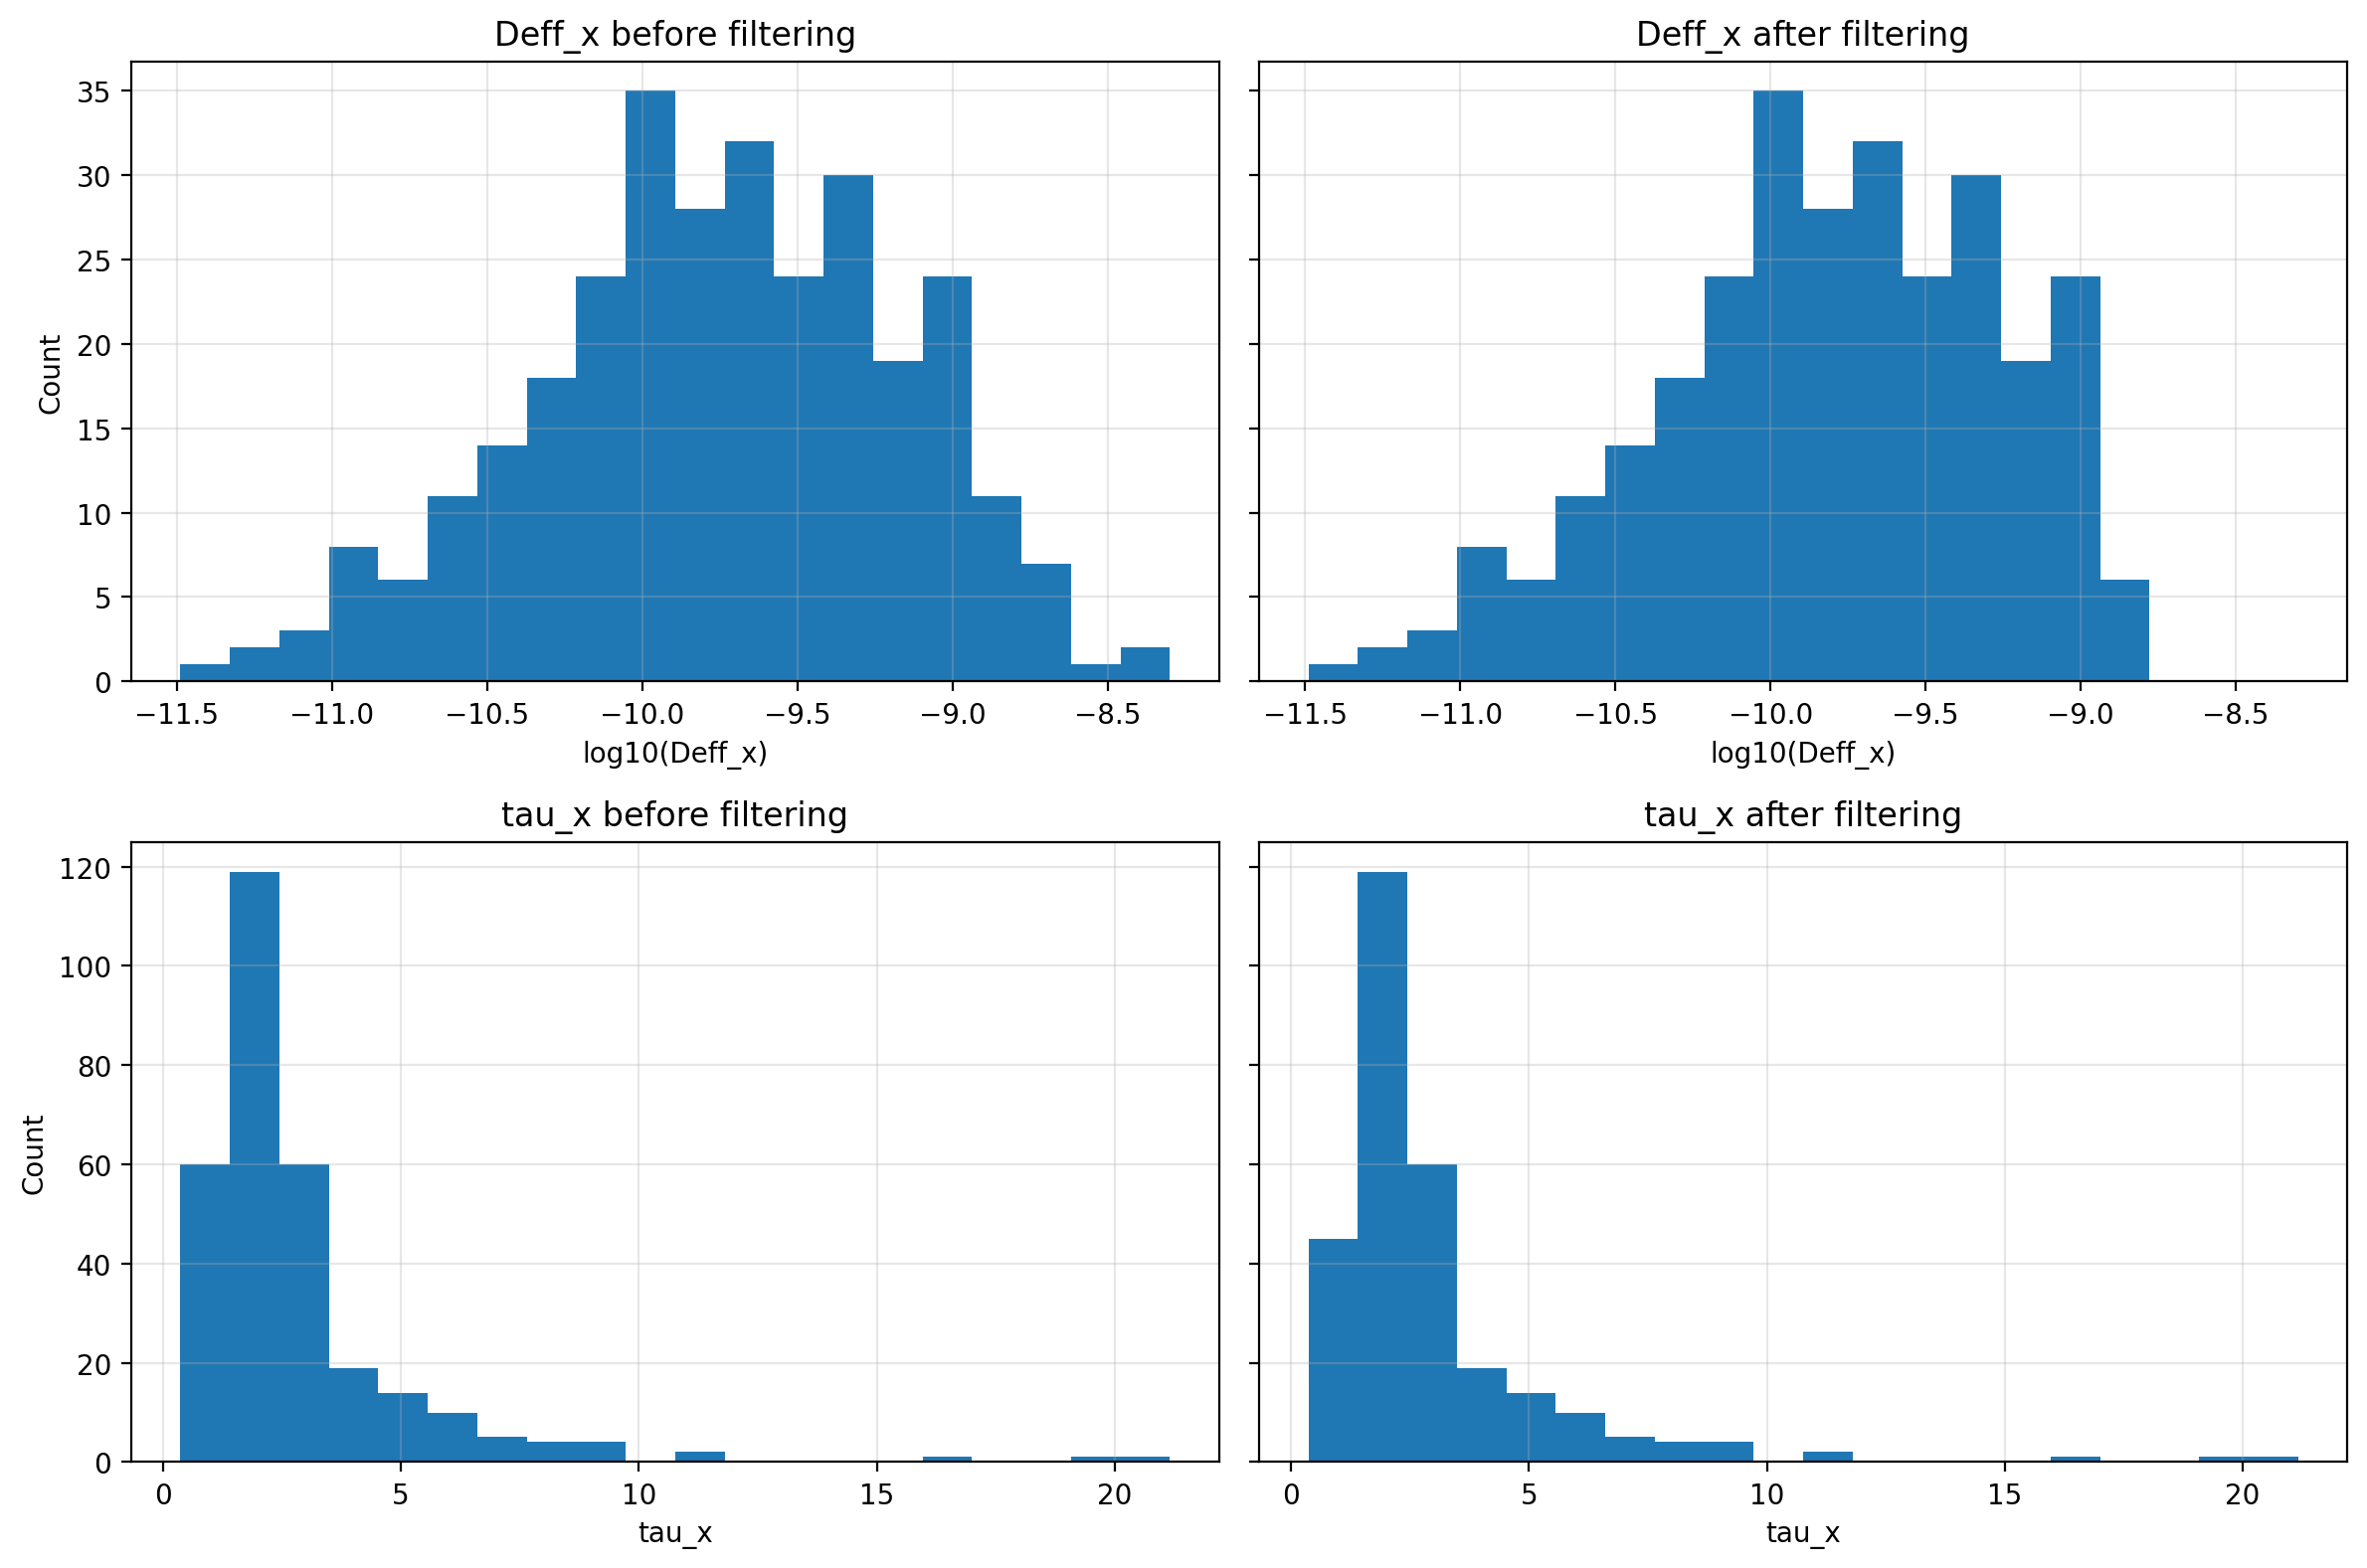

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey="row")

deff_before = np.log10(df["Deff_x"])
deff_after = np.log10(df_clean["Deff_x"])
bins_deff = np.linspace(
    min(deff_before.min(), deff_after.min()),
    max(deff_before.max(), deff_after.max()),
    21
)

tau_before = df["tau_x"]
tau_after = df_clean["tau_x"]
bins_tau = np.linspace(
    min(tau_before.min(), tau_after.min()),
    max(tau_before.max(), tau_after.max()),
    21
)

axes[0, 0].hist(deff_before, bins=bins_deff)
axes[0, 0].set_title("Deff_x before filtering")
axes[0, 0].set_xlabel("log10(Deff_x)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(deff_after, bins=bins_deff)
axes[0, 1].set_title("Deff_x after filtering")
axes[0, 1].set_xlabel("log10(Deff_x)")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(tau_before, bins=bins_tau)
axes[1, 0].set_title("tau_x before filtering")
axes[1, 0].set_xlabel("tau_x")
axes[1, 0].set_ylabel("Count")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(tau_after, bins=bins_tau)
axes[1, 1].set_title("tau_x after filtering")
axes[1, 1].set_xlabel("tau_x")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
df_raw = df.copy()
df_removed = df[df["flag_bad"]].copy()

with pd.ExcelWriter("pnm_dataset_all_versions.xlsx") as writer:
    df_raw.to_excel(writer, sheet_name="raw_300", index=False)
    df_clean.to_excel(writer, sheet_name="clean_285", index=False)
    df_removed.to_excel(writer, sheet_name="removed_15", index=False)

print("Saved: pnm_dataset_all_versions.xlsx")

Saved: pnm_dataset_all_versions.xlsx
